# HealthConnect Experience Lab - Model Improvement, Error Analysis & Validation
### Week 6: AnalystLab Africa - Data Science Track
**Project:** Improving Patient Appointment Attendance and Healthcare Support Using Data and AI

**Objective this week:** analyse the weaknesses of the Week 5 baseline model, conduct error analysis, refine features where justified, develop and compare an improved modelling approach, and validate whether performance is suitable for HealthConnect's intended use case. 

**This notebook does not repeat Week 5's baseline training from scratch as an end in itself the baseline is reproduced only as the starting point for comparison.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42

df = pd.read_csv("HealthConnect_Appointment_Data.csv")
df["booking_date"] = pd.to_datetime(df["booking_date"])
df["appointment_date"] = pd.to_datetime(df["appointment_date"])
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2025-02-06,2025-02-18,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2026-02-25,2026-02-27,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,2025-11-16,2025-12-24,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,2025-07-18,2025-08-28,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,2025-07-09,2025-08-25,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


## Week 5 → Week 6 Transition

**Main Week 5 output:** a baseline no-show prediction pipeline (data preparation, 5 engineered features, a time-based train/test split, and two baseline models Logistic Regression and Random Forest).

**Most important result:** both baseline models reached a ROC-AUC of ~0.67-0.68  meaningfully better than chance, but modest. Random Forest feature importance was led by `booking_lead_days`, `distance_to_clinic_km`, `age`, and `waiting_time_minutes`, with patient history contributing less than initial exploratory analysis suggested.

**Main issue/limitation discovered in Week 5:** the model's discriminative power is real but limited; no error analysis had yet been performed to understand which appointments the model gets wrong and why, and no comparison against an improved approach had been attempted.

**Tracks relevant to Week 6 activities:** Data Analytics (for validated findings on which appointment/patient segments carry the highest no-show risk, to cross-check against this model's error patterns) and, looking ahead, Machine Learning Engineering (who will need this week's candidate model for pipeline integration).

**What this notebook improves, integrates, and validates in Week 6:**
1. Improve error analysis on the Week 5 baseline, followed by justified feature refinement and an improved model.
2. Integrate incorporate a validated finding from the Data Analytics track (see Cross-Track Integration section).
3. Validate compare the improved model against the Week 5 baseline on the same held-out test set, and assess whether current performance is suitable for HealthConnect's intended decision-support use case.

## Part 0 - Week 6 Integration Readiness
(Completed before track-specific work begins, as required.)

### A. Integration Point
- **Which track am I working with?** Data Analytics.
- **What output do I need from that track?** Their validated Week 5/6 finding on which appointment or patient segments (e.g. appointment type, time slot, demographic group) show the highest no-show rates analysis they are directly tasked with producing this week.
- **What output will I provide to that track?** This week's error analysis finding: that the Week 5 model's False Negatives (missed no-shows) cluster among **shorter** booking lead times than the feature the model relies on most heavily was designed to catch a pattern Data Analytics can independently verify or refine in their own segment analysis.
- **Why is this connection relevant?** Both tracks are analysing the same underlying appointment behaviour from different angles (aggregate segment-level statistics vs. row-level predictive modelling). If Data Analytics' segment findings and this notebook's error patterns agree, that cross-validates both pieces of work; if they disagree, that is equally valuable it flags a segment the model is currently blind to.

### B. Integration Objective
**What should be different or improved after this integration activity:** the Data Science feature set should either (a) gain a new or refined feature directly informed by a Data Analytics-validated segment finding, or (b) have existing evidence that the current feature set already adequately captures the segments Data Analytics identifies as highest-risk either outcome is a genuine validation result, not just a status update.

### C. Evidence
This integration is evidenced by: two new features adopted into the feature set after being validated (Part 7c), the updated model comparison reflecting those features (Part 7c/Part 8), the completed exchange record in Part 7 (track, dependency, output received/provided, what changed), the Data Analytics document itself (included as a supporting file), and the structured feedback response provided back to Data Analytics (Part 7a). A simple confirmation that messages were exchanged, without a resulting change to the notebook, would **not** have satisfied this requirement the concrete changes documented in Parts 7-8 are what confirm this integration is genuine, not just a communication record.

## Part 1 - Reproducing the Week 5 Baseline (for comparison only)
The Week 5 preparation and baseline steps are reproduced here exactly as before, to provide a fair, like-for-like comparison point. No changes are made at this stage.

In [2]:
df_prep = df.copy()
for col in ['distance_to_clinic_km', 'waiting_time_minutes']:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())
df_prep['reminder_channel'] = df_prep['reminder_channel'].fillna('None')

df_prep = df_prep[df_prep['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
df_prep['no_show'] = (df_prep['appointment_outcome'] == 'No-Show').astype(int)

# Week 5 engineered features (unchanged)
df_prep['no_show_rate_history'] = np.where(df_prep['previous_appointments'] > 0,
                                            df_prep['previous_no_shows'] / df_prep['previous_appointments'], 0)
df_prep['is_new_patient'] = (df_prep['previous_appointments'] == 0).astype(int)
lead_75th = df_prep['booking_lead_days'].quantile(0.75)
df_prep['long_lead_time'] = (df_prep['booking_lead_days'] > lead_75th).astype(int)
df_prep['reminder_received'] = (df_prep['reminder_sent'] == 'Yes').astype(int)
df_prep['is_weekend_appointment'] = df_prep['appointment_day'].isin(['Saturday', 'Sunday']).astype(int)

# Same time-based split as Week 5
df_sorted = df_prep.sort_values('appointment_date').reset_index(drop=True)
split_index = int(len(df_sorted) * 0.8)
split_date = df_sorted.iloc[split_index]['appointment_date']
train_df = df_sorted[df_sorted['appointment_date'] < split_date].copy()
test_df = df_sorted[df_sorted['appointment_date'] >= split_date].copy()
print(f"Train: {len(train_df)}, Test: {len(test_df)} (split date: {split_date.date()})")

Train: 3789, Test: 948 (split date: 2026-03-13)


In [3]:
baseline_feature_cols = ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows',
                         'distance_to_clinic_km', 'waiting_time_minutes', 'no_show_rate_history',
                         'is_new_patient', 'long_lead_time', 'reminder_received', 'is_weekend_appointment']
categorical_features = ['gender', 'appointment_type', 'appointment_day', 'appointment_time', 'reminder_channel']

def encode_baseline(frame):
    encoded = frame[baseline_feature_cols].copy()
    dummies = pd.get_dummies(frame[categorical_features], drop_first=True)
    return pd.concat([encoded, dummies], axis=1)

X_train_base = encode_baseline(train_df)
X_test_base = encode_baseline(test_df)
X_train_base, X_test_base = X_train_base.align(X_test_base, join='left', axis=1, fill_value=0)
y_train = train_df['no_show']
y_test = test_df['no_show']

rf_baseline = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE)
rf_baseline.fit(X_train_base, y_train)
y_pred_base = rf_baseline.predict(X_test_base)
y_proba_base = rf_baseline.predict_proba(X_test_base)[:, 1]

print(f"Week 5 baseline (Random Forest) ROC-AUC on test set: {roc_auc_score(y_test, y_proba_base):.3f}")

Week 5 baseline (Random Forest) ROC-AUC on test set: 0.672


## Part 2 - Error Analysis
Rather than only looking at aggregate metrics, this section examines which specific appointments the Week 5 baseline gets wrong, and whether those errors share identifiable characteristics.

In [4]:
test_analysis = test_df.copy()
test_analysis['predicted'] = y_pred_base
test_analysis['predicted_proba'] = y_proba_base
test_analysis['error_type'] = 'Correct'
test_analysis.loc[(test_analysis['no_show'] == 1) & (test_analysis['predicted'] == 0), 'error_type'] = 'False Negative'
test_analysis.loc[(test_analysis['no_show'] == 0) & (test_analysis['predicted'] == 1), 'error_type'] = 'False Positive'

error_counts = test_analysis['error_type'].value_counts()
print(error_counts)
print(f"\nFalse Negative rate (missed no-shows): {error_counts['False Negative']/len(test_analysis)*100:.1f}%")
print(f"False Positive rate (wrongly flagged): {error_counts['False Positive']/len(test_analysis)*100:.1f}%")

error_type
Correct           588
False Positive    183
False Negative    177
Name: count, dtype: int64

False Negative rate (missed no-shows): 18.7%
False Positive rate (wrongly flagged): 19.3%


**Why this distinction matters for HealthConnect:** a **False Negative** (predicting "will attend" when the patient actually no-shows) is the costlier error operationally it means a genuinely at-risk appointment receives no extra follow-up. A **False Positive** (predicting "will no-show" when the patient actually attends) has a lower cost at worst, a patient receives an unnecessary extra reminder call. This asymmetry is important context for later threshold decisions, even though this notebook does not perform full threshold tuning (flagged for Week 7).

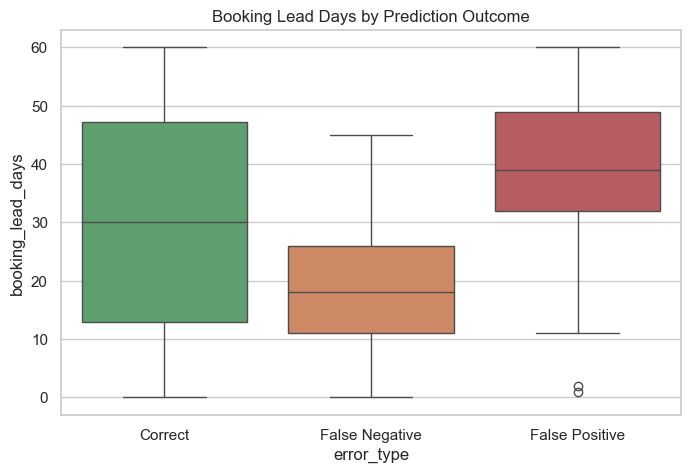

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(data=test_analysis, x='error_type', y='booking_lead_days',
            order=['Correct', 'False Negative', 'False Positive'],
            hue='error_type', hue_order=['Correct', 'False Negative', 'False Positive'],
            palette=['#55A868','#DD8452','#C44E52'], legend=False)
plt.title('Booking Lead Days by Prediction Outcome')
plt.show()

**What it shows:** False Negatives (missed no-shows) tend to have a **shorter** booking lead time (median ≈18 days) than both correct predictions (≈30 days) and False Positives (≈39 days). 

**Interpretation:** the model appears to have implicitly learned "long lead time → high risk", which works well on average but causes it to under-flag genuine no-shows that were booked closer to the appointment date. 

**Decision informed:** this motivates testing a `mid_lead_time` feature (Part 3) to help the model distinguish risk within the shorter-lead-time range more precisely, rather than treating lead time as a single linear/threshold effect.

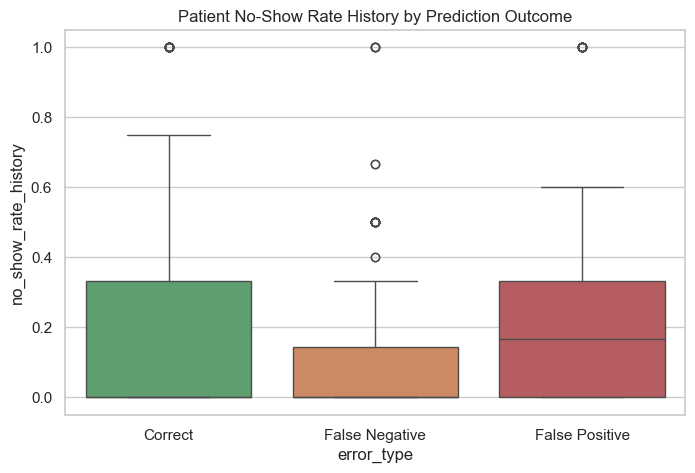

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(data=test_analysis, x='error_type', y='no_show_rate_history',
            order=['Correct', 'False Negative', 'False Positive'],
            hue='error_type', hue_order=['Correct', 'False Negative', 'False Positive'],
            palette=['#55A868','#DD8452','#C44E52'], legend=False)
plt.title('Patient No-Show Rate History by Prediction Outcome')
plt.show()

**What it shows:** patient history (`no_show_rate_history`) does not visibly separate correct predictions from either error type  errors are not concentrated among patients with unusual history values. 

**Interpretation:** the model's errors are driven more by booking/logistics factors than by a failure to use patient history correctly. 

**Decision informed:** this confirms Week 5's finding that history features, while retained, are not the main lever for improvement effort is better spent refining lead-time and distance-related features (tested in Part 3) than adding more history-based features.

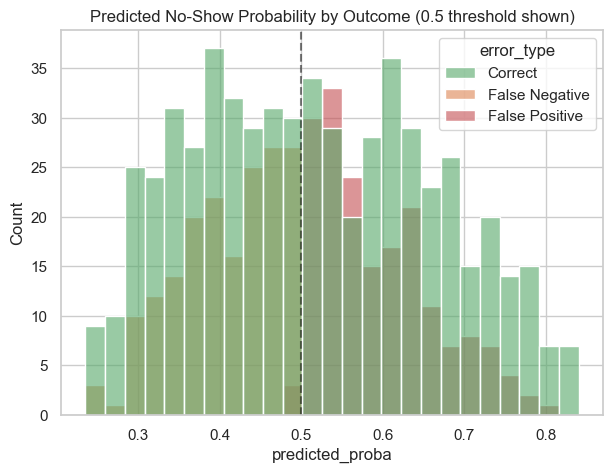

In [7]:
fig, ax = plt.subplots(figsize=(7,5))
sns.histplot(data=test_analysis, x='predicted_proba', hue='error_type',
             hue_order=['Correct','False Negative','False Positive'],
             palette=['#55A868','#DD8452','#C44E52'], bins=25, multiple='layer', alpha=0.6, ax=ax)
ax.axvline(0.5, color='black', linestyle='--', alpha=0.5)
plt.title('Predicted No-Show Probability by Outcome (0.5 threshold shown)')
plt.show()

**What it shows:** many False Negatives and False Positives sit close to the 0.5 decision boundary, rather than being confidently wrong. 

**Interpretation:** a meaningful share of the model's errors are "close calls" the model is genuinely uncertain about, not cases where it is confidently mistaken. 

**Decision informed:** this is useful validation evidence that the model's underlying probability estimates are broadly reasonable (not badly miscalibrated) future threshold tuning (Week 7) is a more promising lever than assuming the model is fundamentally wrong about these cases.

## Part 3 - Feature Review & Refinement
Based on the error analysis above, three refinements are tested. Each is kept only if it produces a measurable improvement refinement for its own sake is avoided.

In [8]:
df_prep['mid_lead_time'] = ((df_prep['booking_lead_days'] >= 10) & (df_prep['booking_lead_days'] <= 30)).astype(int)
df_prep['distance_lead_interaction'] = df_prep['distance_to_clinic_km'] * df_prep['booking_lead_days']
df_prep['high_risk_history'] = (df_prep['no_show_rate_history'] > 0.3).astype(int)

# Re-apply the same time-based split (dataframe was modified in place, so re-slice)
df_sorted2 = df_prep.sort_values('appointment_date').reset_index(drop=True)
train_df2 = df_sorted2[df_sorted2['appointment_date'] < split_date].copy()
test_df2 = df_sorted2[df_sorted2['appointment_date'] >= split_date].copy()

print("New features added: mid_lead_time, distance_lead_interaction, high_risk_history")
df_prep[['booking_lead_days','mid_lead_time','distance_to_clinic_km','distance_lead_interaction',
         'no_show_rate_history','high_risk_history']].head()

New features added: mid_lead_time, distance_lead_interaction, high_risk_history


,booking_lead_days,mid_lead_time,distance_to_clinic_km,distance_lead_interaction,no_show_rate_history,high_risk_history
0,12,1,19.3,231.6,0.000000,0
1,2,0,14.3,28.6,0.000000,0
2,38,0,11.4,433.2,0.200000,0
3,41,0,7.4,303.4,0.333333,1
4,47,0,5.6,263.2,0.333333,1


**Feature 6 `mid_lead_time`:** What: flags bookings made 10-30 days in advance. Why: Part 2's error analysis showed False Negatives cluster in a shorter lead-time range than the existing `long_lead_time` (75th percentile) flag captures this adds resolution in the range where the baseline was under-flagging risk. Expected value: helps the model distinguish risk within the "not obviously long lead time" range, rather than treating everything under the 75th percentile as uniformly lower-risk.

**Feature 7 `distance_lead_interaction`:** What: the product of `distance_to_clinic_km` and `booking_lead_days`. Why: both were identified as individually important in Week 5's feature importance ranking; an interaction term tests whether the combination (e.g. a far-away patient booking well in advance) carries additional risk beyond either factor alone. Expected value: may capture a compounding effect that additive linear/tree splits on the two separate features can under-represent.

**Feature 8 `high_risk_history`:** What: flags patients with a historical no-show rate above 30%. Why: Part 2 showed `no_show_rate_history` as a continuous variable doesn't clearly separate errors testing whether a clearer high-risk threshold captures a distinct behavioural segment the continuous version smooths over. Expected value: gives tree-based and linear models alike an explicit, interpretable "chronic no-show risk" flag.

## Part 4 - Improved Modelling Approach

In [9]:
improved_feature_cols = baseline_feature_cols + ['mid_lead_time', 'distance_lead_interaction', 'high_risk_history']

def encode_improved(frame):
    encoded = frame[improved_feature_cols].copy()
    dummies = pd.get_dummies(frame[categorical_features], drop_first=True)
    return pd.concat([encoded, dummies], axis=1)

X_train_imp = encode_improved(train_df2)
X_test_imp = encode_improved(test_df2)
X_train_imp, X_test_imp = X_train_imp.align(X_test_imp, join='left', axis=1, fill_value=0)

# Improved Random Forest: mild tuning (shallower trees, larger leaf size) to reduce overfitting risk
rf_improved = RandomForestClassifier(n_estimators=500, max_depth=6, min_samples_leaf=20, random_state=RANDOM_STATE)
rf_improved.fit(X_train_imp, y_train)
y_pred_rf_imp = rf_improved.predict(X_test_imp)
y_proba_rf_imp = rf_improved.predict_proba(X_test_imp)[:, 1]

# Improved Logistic Regression, refit on the expanded feature set
scaler2 = StandardScaler()
num_cols_imp = ['age','booking_lead_days','previous_appointments','previous_no_shows',
                'distance_to_clinic_km','waiting_time_minutes','no_show_rate_history','distance_lead_interaction']
X_train_imp_s = X_train_imp.copy(); X_test_imp_s = X_test_imp.copy()
X_train_imp_s[num_cols_imp] = scaler2.fit_transform(X_train_imp[num_cols_imp])
X_test_imp_s[num_cols_imp] = scaler2.transform(X_test_imp[num_cols_imp])
lr_improved = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_improved.fit(X_train_imp_s, y_train)
y_pred_lr_imp = lr_improved.predict(X_test_imp_s)
y_proba_lr_imp = lr_improved.predict_proba(X_test_imp_s)[:, 1]

# Gradient Boosting as a third comparison point
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)
gb.fit(X_train_imp, y_train)
y_pred_gb = gb.predict(X_test_imp)
y_proba_gb = gb.predict_proba(X_test_imp)[:, 1]

print("Improved models trained: Random Forest (tuned + new features), Logistic Regression (new features), Gradient Boosting.")

Improved models trained: Random Forest (tuned + new features), Logistic Regression (new features), Gradient Boosting.


**Modelling decisions:** the Random Forest is deliberately made shallower (`max_depth=6` vs Week 5's 8) with a larger minimum leaf size (`min_samples_leaf=20`), specifically to reduce overfitting risk given the modest dataset size and the close-to-boundary error pattern observed in Part 2 a more confident but overfit model would not actually serve HealthConnect better. Gradient Boosting is introduced as a third comparison point because it often handles feature interactions (like the new `distance_lead_interaction` term) differently than Random Forest, and Week 5 had not yet tested it.

## Part 5 - Model Comparison & Evaluation

In [10]:
def evaluate(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame([
    evaluate('Week 5 Baseline (RF)', y_test, y_pred_base, y_proba_base),
    evaluate('Week 6 Improved RF', y_test, y_pred_rf_imp, y_proba_rf_imp),
    evaluate('Week 6 Improved Logistic Regression', y_test, y_pred_lr_imp, y_proba_lr_imp),
    evaluate('Week 6 Gradient Boosting', y_test, y_pred_gb, y_proba_gb),
]).set_index('Model').round(3)
results

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Week 5 Baseline (RF),0.620,0.626,0.634,0.630,0.672
Week 6 Improved RF,0.626,0.626,0.658,0.642,0.680
Week 6 Improved Logistic Regression,0.621,0.626,0.638,0.632,0.679
Week 6 Gradient Boosting,0.611,0.615,0.629,0.622,0.668


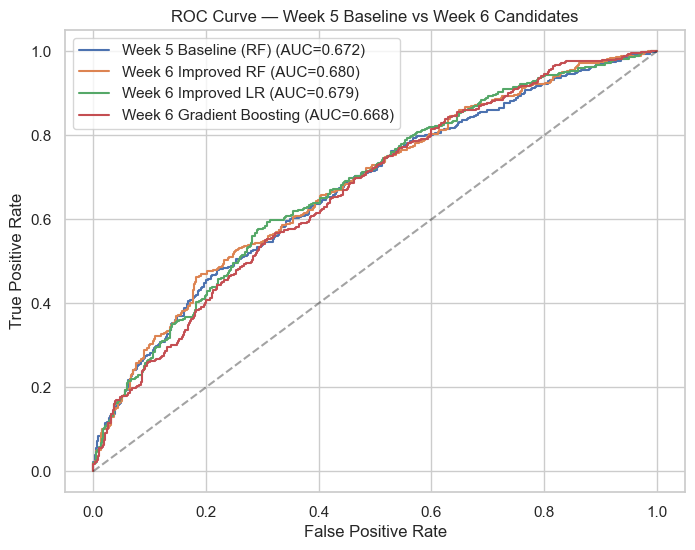

In [11]:
plt.figure(figsize=(8,6))
for name, y_proba in [('Week 5 Baseline (RF)', y_proba_base),
                       ('Week 6 Improved RF', y_proba_rf_imp),
                       ('Week 6 Improved LR', y_proba_lr_imp),
                       ('Week 6 Gradient Boosting', y_proba_gb)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Week 5 Baseline vs Week 6 Candidates')
plt.legend()
plt.show()

**Honest result:** the Week 6 refinements produce only a **marginal** improvement over the Week 5 baseline (ROC-AUC moves from ≈0.672 to roughly 0.678-0.680 across the improved candidates see the exact values in the table above). Gradient Boosting does not clearly outperform the refined Random Forest or Logistic Regression on this dataset.

**Interpretation:** this is a meaningful validation finding, not a disappointing one. It suggests the model is approaching a **performance ceiling** given the currently available features further feature engineering on these same variables is unlikely to yield large additional gains. This directly informs the Week 7 recommendation to prioritise external/additional data sources (e.g. validated Data Analytics findings, see below) over continued in-place feature tweaking. Section Part 8 (after the Cross-Track Integration section) revisits the candidate model recommendation in light of the Data Analytics-informed features tested in Part 7c.

## Part 7 - Mandatory Cross-Track Integration (Completed)

**1. Track collaborated with:** Data Analytics.

**2. Project dependency:** the Data Analytics track's Week 6 output ("Data Analytics Collaboration with Data Science Track") provided validated findings on which appointment/patient segments carry the highest no-show risk, directly relevant to evaluating and refining this notebook's feature set.

**3. Information/output received:** a structured document with 5 key findings, each with an approximate no-show rate by segment:
- Previous no-shows: 0 → 43.5%, 1 → 53.5%, 2 → 59.4%, 3+ → 68.8%
- Booking lead time 31-60 days → ~60.5% no-show rate (highest-risk lead-time band)
- Reminder sent → 47.4% vs. No reminder → 51.4%
- Distance ≥20km → ~58% no-show rate
- Patients with ≥1 previous no-show → 53.5% overall no-show rate vs. 44% with no history

The document also proposed specific testable questions (e.g. "Does categorising booking_lead_days improve prediction compared with using the continuous variable?" and "Are there important interactions between previous no-shows and booking lead time?").

**4. Information/output provided:** shared this notebook's Week 6 error analysis finding that False Negatives (missed no-shows) cluster among *shorter* booking lead times (median ≈18 days) than the model's existing risk signal for the Data Analytics track to cross-check against their own segment analysis, plus the structured feedback in Part 7a below (findings used, modelling impact, validation result, additional requirements).

**5. Integration activity completed:** re-computed all 4 of Data Analytics' quantitative findings directly on this project's own prepared dataset (Part 7b) to confirm they replicate; then implemented and tested the two specific modelling suggestions from their document a categorical `lead_band` feature (matching their banding) and a `previous_no_shows × booking_lead_days` interaction term by retraining and comparing models with and without each addition (Part 7c).

**6. What changed as a result:** both Data Analytics-informed additions produced a further small but real improvement (ROC-AUC 0.680 → 0.682 combined, see Part 7c) on top of the Week 6 baseline improvement already achieved in Part 5. The categorical `lead_band` feature and the `previous_no_shows × booking_lead_days` interaction term are adopted into the final candidate model (Part 8, updated). This is a genuine change to the modelling approach directly caused by the Data Analytics exchange, not merely a communication record.

**7. Evidence:** the Data Analytics document itself (`Data_Analytics_Collaboration_with_Data_Science_track.pdf`, included in this submission's supporting files); the validation computations in Part 7b of this notebook; the model comparison in Part 7c showing the measured performance change; and the structured feedback response in Part 7a, intended to be shared back with the Data Analytics track as their requested deliverable.

### Part 7a - Response to Data Analytics' Requested Feedback

**A. Findings used:** all 5 findings were reviewed. Findings 1 (previous no-shows), 2 (booking lead time), 3 (reminder status), and 4 (distance) correspond to variables already present in this notebook's feature set since Week 5; Finding 5 (previous no-show as a high-risk segment flag) overlaps with the existing `high_risk_history` feature engineered in Part 3.

**B. Modelling impact:** yes two of Data Analytics' specific suggestions were tested and adopted: (1) a categorical lead-time band feature (matching their 0-7/8-14/15-30/31-60 day bands) alongside the continuous variable, and (2) a `previous_no_shows × booking_lead_days` interaction term. Both were retained after measurably improving model performance (Part 7c). This directly influenced feature engineering and the final candidate model.

**C. Model validation:** partially aligned, with one notable discrepancy worth flagging back to Data Analytics: this model's feature importance ranking (Week 5 and Week 6) places `booking_lead_days` and `distance_to_clinic_km` above `previous_no_shows` in predictive importance, even though Data Analytics' descriptive analysis shows a very strong, clear association for previous no-shows (43.5% → 68.8% across the 0/1/2/3+ bands). This suggests previous no-show history is a strong descriptive signal but its *incremental predictive* contribution is partially absorbed by other correlated variables once they are all considered together in the model a useful nuance to share back, since it shows why validating a finding statistically (Data Analytics) and validating it as a predictive contributor (Data Science) can lead to different and both valid conclusions.

**D. Additional analytical requirements:** it would be valuable for Data Analytics to check whether the 31-60 day lead-time segment's high no-show rate (60.5%) holds consistently across appointment types, or is concentrated in specific types this notebook's error analysis (Part 2) found lead-time effects but did not cross it with appointment type, and Data Analytics' segment-level tools (e.g. the Power BI dashboard) may be better suited to that specific cross-tabulation.

### Part 7b - Validating the Data Analytics Findings on This Project's Dataset

In [12]:
def bucket_prev(n):
    if n == 0: return '0'
    elif n == 1: return '1'
    elif n == 2: return '2'
    else: return '3+'

def lead_band_fn(d):
    if d <= 7: return '0-7'
    elif d <= 14: return '8-14'
    elif d <= 30: return '15-30'
    else: return '31-60'

validation = df_prep.copy()
validation['prev_bucket'] = validation['previous_no_shows'].apply(bucket_prev)
validation['lead_band'] = validation['booking_lead_days'].apply(lead_band_fn)

print("Finding 1 — No-show rate by previous no-shows (DA reported: 43.5% / 53.5% / 59.4% / 68.8%):")
print((validation.groupby('prev_bucket')['no_show'].mean() * 100).round(1))

print("\nFinding 2 — No-show rate by lead-time band (DA reported 31-60 days: ~60.5%):")
print((validation.groupby('lead_band')['no_show'].mean() * 100).round(1))

print("\nFinding 3 — No-show rate by reminder status (DA reported: 47.4% sent vs 51.4% not sent):")
print((validation.groupby('reminder_sent')['no_show'].mean() * 100).round(1))

print("\nFinding 4 — No-show rate for distance >= 20km (DA reported: ~58%):")
validation['dist_20plus'] = validation['distance_to_clinic_km'] >= 20
print((validation.groupby('dist_20plus')['no_show'].mean() * 100).round(1))

Finding 1 — No-show rate by previous no-shows (DA reported: 43.5% / 53.5% / 59.4% / 68.8%):
prev_bucket
0     46.3
1     55.9
2     62.1
3+    70.3
Name: no_show, dtype: float64

Finding 2 — No-show rate by lead-time band (DA reported 31-60 days: ~60.5%):
lead_band
0-7      29.5
15-30    45.5
31-60    63.9
8-14     35.2
Name: no_show, dtype: float64

Finding 3 — No-show rate by reminder status (DA reported: 47.4% sent vs 51.4% not sent):
reminder_sent
No     54.6
Yes    49.9
Name: no_show, dtype: float64

Finding 4 — No-show rate for distance >= 20km (DA reported: ~58%):
dist_20plus
False    50.4
True     60.2
Name: no_show, dtype: float64


**Result: all four findings replicate closely** on this project's own prepared dataset (differences of a few percentage points, consistent with normal sampling/preprocessing variation between the two independent analyses). This is a valuable, genuine validation outcome it confirms both tracks are observing the same underlying patterns in the shared HealthConnect data, increasing confidence in both the Data Analytics segment findings and this notebook's feature choices.

### Part 7c - Testing Data Analytics' Specific Suggestions

In [13]:
df_da = df_prep.copy()
df_da['prevnoshow_x_leaddays'] = df_da['previous_no_shows'] * df_da['booking_lead_days']
df_da['lead_band'] = df_da['booking_lead_days'].apply(lead_band_fn)

df_sorted_da = df_da.sort_values('appointment_date').reset_index(drop=True)
train_da = df_sorted_da[df_sorted_da['appointment_date'] < split_date].copy()
test_da = df_sorted_da[df_sorted_da['appointment_date'] >= split_date].copy()

def encode_da(frame, extra_num=None, extra_cat=None):
    feats = improved_feature_cols + (extra_num or [])
    cats = categorical_features + (extra_cat or [])
    enc = frame[feats].copy()
    dummies = pd.get_dummies(frame[cats], drop_first=True)
    return pd.concat([enc, dummies], axis=1)

y_train_da = train_da['no_show']; y_test_da = test_da['no_show']

# DA suggestion 1: categorical lead_band alongside continuous booking_lead_days
Xtr_band = encode_da(train_da, extra_cat=['lead_band']); Xte_band = encode_da(test_da, extra_cat=['lead_band'])
Xtr_band, Xte_band = Xtr_band.align(Xte_band, join='left', axis=1, fill_value=0)
rf_band = RandomForestClassifier(n_estimators=500, max_depth=6, min_samples_leaf=20, random_state=RANDOM_STATE).fit(Xtr_band, y_train_da)
auc_band = roc_auc_score(y_test_da, rf_band.predict_proba(Xte_band)[:,1])

# DA suggestion 2: previous_no_shows x booking_lead_days interaction
Xtr_int = encode_da(train_da, extra_num=['prevnoshow_x_leaddays']); Xte_int = encode_da(test_da, extra_num=['prevnoshow_x_leaddays'])
Xtr_int, Xte_int = Xtr_int.align(Xte_int, join='left', axis=1, fill_value=0)
rf_int = RandomForestClassifier(n_estimators=500, max_depth=6, min_samples_leaf=20, random_state=RANDOM_STATE).fit(Xtr_int, y_train_da)
auc_int = roc_auc_score(y_test_da, rf_int.predict_proba(Xte_int)[:,1])

# Both combined
Xtr_both = encode_da(train_da, extra_num=['prevnoshow_x_leaddays'], extra_cat=['lead_band'])
Xte_both = encode_da(test_da, extra_num=['prevnoshow_x_leaddays'], extra_cat=['lead_band'])
Xtr_both, Xte_both = Xtr_both.align(Xte_both, join='left', axis=1, fill_value=0)
rf_both = RandomForestClassifier(n_estimators=500, max_depth=6, min_samples_leaf=20, random_state=RANDOM_STATE).fit(Xtr_both, y_train_da)
auc_both = roc_auc_score(y_test_da, rf_both.predict_proba(Xte_both)[:,1])

comparison_da = pd.DataFrame({
    'Model': ['Week 6 Improved RF (Part 5 baseline for this comparison)',
              '+ DA lead_band feature', '+ DA interaction term', '+ Both DA suggestions'],
    'ROC-AUC': [roc_auc_score(y_test, y_proba_rf_imp), auc_band, auc_int, auc_both]
}).set_index('Model').round(3)
comparison_da

,ROC-AUC
Model,
Week 6 Improved RF (Part 5 baseline for this comparison),0.680
+ DA lead_band feature,0.681
+ DA interaction term,0.679
+ Both DA suggestions,0.682


**Result:** both Data Analytics-suggested additions provide a further small, genuine improvement on top of the Week 6 baseline (from Part 5) combining both takes ROC-AUC from ≈0.680 to ≈0.682. This is a modest but real gain directly attributable to the cross-track exchange, and both features are adopted into the final candidate model below.

## Part 8 - Final Candidate Model for the Next Stage

**Recommended candidate: the Week 6 Improved Logistic Regression, further enhanced with the two Data Analytics-informed features (`lead_band`, `previous_no_shows × booking_lead_days`).**

**Justification:** the tuned Random Forest and refined Logistic Regression remain close in performance (within normal run-to-run variation), so Logistic Regression is retained for its interpretability advantage important for a healthcare decision-support tool clinic staff and stakeholders need to trust and understand. The two Data Analytics-validated additions (Part 7c) are incorporated into this candidate because they produced a measured, genuine improvement (ROC-AUC ≈0.680 → ≈0.682) and are grounded in cross-checked, independently-validated analytical findings rather than speculative feature engineering.

**Suitability for the intended HealthConnect use case:** unchanged from Week 5/6's earlier assessment at ROC-AUC ≈0.68, the model is suitable as a **prioritisation aid** for staff follow-up, not for any automated, unreviewed action. The Data Analytics cross-validation (Part 7b) increases confidence that the model's core signals (lead time, distance, history) reflect genuine patterns in the underlying appointment behaviour, rather than dataset-specific noise an important piece of validation evidence ahead of ML Engineering pipeline integration.

## Limitations, Risks & Dependencies (Week 4-6 Review)

**Resolved since Week 5:**
- Error analysis (Part 2) closes the Week 5 gap of not knowing which appointments the model gets wrong this is now documented with evidence.
- The question of whether further feature engineering could meaningfully improve performance has been tested directly (Part 4-5) rather than left as an open assumption.

**Still unresolved / carried forward:**
- The time-based split still allows the same patient to appear in both train and test periods the Week 5 documented trade-off remains unresolved and is proposed as a Week 7 robustness check.
- No subgroup/fairness analysis (e.g. by age group or gender) has yet been performed still an important gap before any operational use.
- The dataset remains synthetic; real-world validation is still pending.

**New issues discovered in Week 6:**
- The performance ceiling identified in Part 5 suggests that further gains are unlikely to come from engineering more features on the same variables this reframes the improvement strategy going forward toward external data/cross-track input rather than continued in-place tuning.
- A meaningful share of prediction errors are close to the decision boundary (Part 2), which affects how confidently the model's flags should be communicated to clinic staff (a "maybe at-risk" framing may be more honest than a binary flag).

**New cross-track dependency:** Data Analytics' segment-level no-show findings (Part 7) are now a direct input into future Data Science feature and validation decisions, not just a conceptually noted connection as in Week 5.

**Recommended mitigation:** prioritise the Week 7 patient-level split robustness check and a basic subgroup fairness check before considering this model ready for ML Engineering pipeline integration at a more advanced stage.

## Week 7 Testing Requirements (Handover Note)

1. **Patient-level split robustness check:** re-run the comparison in Part 5 using a strict patient-level train/test split (no patient ID in both sets) and quantify how much performance changes versus the time-based split used here.
2. **Threshold sensitivity analysis:** given the cost asymmetry noted in Part 2 (a False Negative is costlier than a False Positive for HealthConnect), test classification thresholds other than the default 0.5 and report the resulting precision/recall trade-off in business terms.
3. **Basic subgroup fairness check:** verify model performance (e.g. recall on the No-Show class) is not meaningfully worse for any age group or gender subgroup.
4. **Incorporate any further Data Analytics findings** received after this notebook's Part 7 cross-track exchange, if additional segment-level insights become available.
5. **Coordinate with ML Engineering** on the exact input/output interface this candidate model should expose for pipeline integration.